In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/README.txt
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20122013.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20072008.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20132014.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20182019.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20212022.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20202021.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20102011.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20162017.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20152016.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20172018.csv
/kaggle/input/nhl-playbyplay-data-from-2007/h

In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        print(root)
        for f in files[:20]:
            print("  ", f)
        if len(files) > 20:
            print("  ...", len(files), "files")


/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data
   README.txt
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp
   nhl_pbp20122013.csv
   nhl_pbp20072008.csv
   nhl_pbp20132014.csv
   nhl_pbp20182019.csv
   nhl_pbp20212022.csv
   nhl_pbp20202021.csv
   nhl_pbp20102011.csv
   nhl_pbp20162017.csv
   nhl_pbp20152016.csv
   nhl_pbp20172018.csv
   nhl_pbp20082009.csv
   nhl_pbp20112012.csv
   nhl_pbp20192020.csv
   nhl_pbp20092010.csv
   nhl_pbp20222023.csv
   nhl_pbp20142015.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/roster
   roster20162017.csv
   roster20112012.csv
   roster20132014.csv
   roster20192020.csv
   roster20072008.csv
   roster20152016.csv
   roster20082009.csv
   roster20102011.csv
   roster20122013.csv
   roster20092010.csv
   roster20182019.csv
   roster20172018.csv
   roster20142015.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/shifts
   nhl_shifts20082009.csv
   nhl_shifts20192020.csv
   nhl

In [2]:
import os

all_csv = []
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".csv"):
            all_csv.append(os.path.join(root, f))

# покажем самые похожие на pbp / player / shift / game
keywords = ["play", "pbp", "event", "player", "shift", "game"]
for kw in keywords:
    hits = [p for p in all_csv if kw in os.path.basename(p).lower()]
    print("\n==", kw, "==")
    for p in hits[:30]:
        print(p)



== play ==

== pbp ==
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20122013.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20072008.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20132014.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20182019.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20212022.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20202021.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20102011.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20162017.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20152016.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20172018.csv
/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp20082009.csv
/kaggle/i

In [3]:
import pandas as pd

# === Выбираем один сезон для старта ===
SEASON = "20142015"  # можешь поменять на 20182019 и т.п.

PBP_PATH = f"/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/pbp/nhl_pbp{SEASON}.csv"
ROSTER_PATH = f"/kaggle/input/nhl-playbyplay-data-from-2007/hockey_scraper_data/roster/roster{SEASON}.csv"

pbp = pd.read_csv(PBP_PATH)
roster = pd.read_csv(ROSTER_PATH)

print("PBP shape:", pbp.shape)
print("Roster shape:", roster.shape)

print("\nPBP columns (first 60):")
print(pbp.columns.tolist()[:60])

print("\nRoster columns:")
print(roster.columns.tolist())

print("\nPBP head:")
display(pbp.head(3))

print("\nRoster head:")
display(roster.head(3))



PBP shape: (422948, 56)
Roster shape: (67304, 5)

PBP columns (first 60):
['Game_Id', 'Date', 'Period', 'Event', 'Description', 'Time_Elapsed', 'Seconds_Elapsed', 'Strength', 'Ev_Zone', 'Type', 'Ev_Team', 'Home_Zone', 'Away_Team', 'Home_Team', 'p1_name', 'p1_ID', 'p2_name', 'p2_ID', 'p3_name', 'p3_ID', 'awayPlayer1', 'awayPlayer1_id', 'awayPlayer2', 'awayPlayer2_id', 'awayPlayer3', 'awayPlayer3_id', 'awayPlayer4', 'awayPlayer4_id', 'awayPlayer5', 'awayPlayer5_id', 'awayPlayer6', 'awayPlayer6_id', 'homePlayer1', 'homePlayer1_id', 'homePlayer2', 'homePlayer2_id', 'homePlayer3', 'homePlayer3_id', 'homePlayer4', 'homePlayer4_id', 'homePlayer5', 'homePlayer5_id', 'homePlayer6', 'homePlayer6_id', 'Away_Players', 'Home_Players', 'Away_Score', 'Home_Score', 'Away_Goalie', 'Away_Goalie_Id', 'Home_Goalie', 'Home_Goalie_Id', 'xC', 'yC', 'Home_Coach', 'Away_Coach']

Roster columns:
['#', 'Pos', 'Name', 'Scratches', 'game_id']

PBP head:


,Game_Id,Date,Period,Event,Description,Time_Elapsed,Seconds_Elapsed,Strength,Ev_Zone,Type,...,Away_Score,Home_Score,Away_Goalie,Away_Goalie_Id,Home_Goalie,Home_Goalie_Id,xC,yC,Home_Coach,Away_Coach
0,20001,2014-10-08,1,PSTR,Period Start- Local time: 7:15 EDT,0:00,0.0,5x5,NaN,NaN,...,0,0,CAREY PRICE,8471679.0,JONATHAN BERNIER,8473541.0,NaN,NaN,RANDY CARLYLE,MICHEL THERRIEN
1,20001,2014-10-08,1,FAC,MTL won Neu. Zone - MTL #51 DESHARNAIS vs TOR ...,0:00,0.0,5x5,Neu,NaN,...,0,0,CAREY PRICE,8471679.0,JONATHAN BERNIER,8473541.0,0.0,0.0,RANDY CARLYLE,MICHEL THERRIEN
2,20001,2014-10-08,1,MISS,"MTL #51 DESHARNAIS, Wrist, Wide of Net, Off. Z...",0:19,19.0,5x5,Off,WRIST SHOT,...,0,0,CAREY PRICE,8471679.0,JONATHAN BERNIER,8473541.0,61.0,29.0,RANDY CARLYLE,MICHEL THERRIEN



Roster head:


,#,Pos,Name,Scratches,game_id
0,10,C,J.T. MILLER,False,2014010067
1,15,L,TANNER GLASS,False,2014010067
2,16,C,DERICK BRASSARD,False,2014010067


In [4]:
import pandas as pd
import numpy as np

# --- 1) Оставляем только 5x5 ---
pbp_5v5 = pbp[pbp["Strength"] == "5x5"].copy()
print("Events 5x5:", len(pbp_5v5))

# --- 2) Колонки игроков на льду ---
home_cols = [f"homePlayer{i}_id" for i in range(1, 7)]
away_cols = [f"awayPlayer{i}_id" for i in range(1, 7)]

print("Home cols:", home_cols)
print("Away cols:", away_cols)

# --- 3) Какие события будем считать "атаками" ---
SHOT_EVENTS = ["SHOT", "MISS", "BLOCK", "GOAL"]   # широкий набор
pbp_att = pbp_5v5[pbp_5v5["Event"].isin(SHOT_EVENTS)].copy()
print("Attacking events 5x5:", len(pbp_att))

# --- 4) Функция: достать 5 полевых (выкинуть вратаря) ---
def get_five_ids(row, side):
    """
    side = 'home' / 'away'
    Возвращает список из 5 полевых игроков (int) или None.
    """
    if side == "home":
        ids = row[home_cols].values
        goalie = row["Home_Goalie_Id"]
    else:
        ids = row[away_cols].values
        goalie = row["Away_Goalie_Id"]

    # убираем NaN
    ids = [int(x) for x in ids if pd.notna(x)]

    # ожидаем 6 человек
    if len(ids) != 6:
        return None

    # убираем вратаря, если он в списке
    if pd.notna(goalie):
        g = int(goalie)
        ids = [x for x in ids if x != g]

    # после удаления вратаря должно остаться 5
    if len(ids) != 5:
        # иногда в данных может быть нестыковка
        return None

    return ids

# --- 5) Функция: "кому засчитать" событие (shot-for) ---
def event_team_is_home(row):
    """
    True, если событие сделала домашняя команда.
    В данных есть Ev_Team (команда события), Home_Team.
    """
    return str(row["Ev_Team"]) == str(row["Home_Team"])

# --- 6) Собираем датасет пятёрок ---
records = []
bad_rows = 0

for _, row in pbp_att.iterrows():
    home5 = get_five_ids(row, "home")
    away5 = get_five_ids(row, "away")
    if home5 is None or away5 is None:
        bad_rows += 1
        continue

    # y: +1 если бросок/гол хозяев, иначе -1
    y = +1.0 if event_team_is_home(row) else -1.0

    records.append({"p1": home5[0], "p2": home5[1], "p3": home5[2], "p4": home5[3], "p5": home5[4], "y": y})
    records.append({"p1": away5[0], "p2": away5[1], "p3": away5[2], "p4": away5[3], "p5": away5[4], "y": -y})

df5 = pd.DataFrame(records)

print("\nBad rows skipped:", bad_rows)
print("Final df5 shape:", df5.shape)
print("\nSample:")
display(df5.head())
print("\ny distribution:", df5["y"].value_counts().to_dict())


Events 5x5: 344589
Home cols: ['homePlayer1_id', 'homePlayer2_id', 'homePlayer3_id', 'homePlayer4_id', 'homePlayer5_id', 'homePlayer6_id']
Away cols: ['awayPlayer1_id', 'awayPlayer2_id', 'awayPlayer3_id', 'awayPlayer4_id', 'awayPlayer5_id', 'awayPlayer6_id']
Attacking events 5x5: 118723

Bad rows skipped: 2972
Final df5 shape: (231502, 6)

Sample:


,p1,p2,p3,p4,p5,y
0,8475098,8473548,8474037,8470602,8462196,-1.0
1,8471976,8469707,8474157,8471296,8474056,1.0
2,8475098,8473548,8474037,8471392,8476478,1.0
3,8469521,8476851,8475848,8471296,8474056,-1.0
4,8475098,8473548,8474037,8471392,8476478,1.0



y distribution: {-1.0: 115751, 1.0: 115751}


In [6]:
# --- Сортируем игроков внутри пятёрки (чтобы {A,B,C,D,E} == {E,D,C,B,A}) ---
players_cols = ["p1", "p2", "p3", "p4", "p5"]

df5_sorted = df5.copy()
df5_sorted[players_cols] = np.sort(df5_sorted[players_cols].values, axis=1)

# --- Агрегируем ---
agg = (
    df5_sorted
    .groupby(players_cols, as_index=False)
    .agg(
        y_mean=("y", "mean"),
        n_obs=("y", "size")
    )
)

print("Aggregated shape:", agg.shape)
print("\nSample aggregated rows:")
display(agg.head())

print("\nDistribution of n_obs:")
display(agg["n_obs"].describe())


Aggregated shape: (45615, 7)

Sample aggregated rows:


,p1,p2,p3,p4,p5,y_mean,n_obs
0,8448208,8460542,8460626,8464977,8476457,1.0,1
1,8448208,8460542,8460626,8467899,8469623,1.0,1
2,8448208,8460542,8460626,8469500,8476923,1.0,3
3,8448208,8460542,8460626,8469623,8471233,1.0,1
4,8448208,8460542,8460626,8471233,8472382,-1.0,1



Distribution of n_obs:


count    45615.000000
mean         5.075129
std         13.612909
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        625.000000
Name: n_obs, dtype: float64

In [7]:
# --- считаем частоты игроков ---
from collections import Counter

cnt = Counter()

for col in players_cols:
    cnt.update(agg[col].values)

print("Total unique players:", len(cnt))

# --- берём топ-N ---
MAX_PLAYERS = 300  # можно 200–400
top_players = [p for p, _ in cnt.most_common(MAX_PLAYERS)]

player_to_idx = {p: i for i, p in enumerate(top_players)}
idx_to_player = {i: p for p, i in player_to_idx.items()}

print("Using players:", len(player_to_idx))


Total unique players: 883
Using players: 300


In [8]:
# --- оставляем только пятёрки из топ-игроков ---
mask = agg[players_cols].apply(
    lambda row: all(p in player_to_idx for p in row),
    axis=1
)

agg_f = agg[mask].reset_index(drop=True)

print("After filtering shape:", agg_f.shape)
print("Share kept:", len(agg_f) / len(agg))


After filtering shape: (3310, 7)
Share kept: 0.07256384961087362


In [9]:
import scipy.sparse as sp

n_samples = len(agg_f)
n_players = len(player_to_idx)

rows, cols, data = [], [], []

for i, row in agg_f.iterrows():
    for p in row[players_cols]:
        rows.append(i)
        cols.append(player_to_idx[p])
        data.append(1.0)

X_ind = sp.csr_matrix((data, (rows, cols)), shape=(n_samples, n_players))
print("X_ind shape:", X_ind.shape, "nnz:", X_ind.nnz)

X_ind shape: (3310, 300) nnz: 16550


In [10]:
from itertools import combinations

pair_to_idx = {}
pair_rows, pair_cols, pair_data = [], [], []

for i, row in agg_f.iterrows():
    ps = [player_to_idx[p] for p in row[players_cols]]
    for a, b in combinations(ps, 2):
        key = (a, b) if a < b else (b, a)
        if key not in pair_to_idx:
            pair_to_idx[key] = len(pair_to_idx)
        j = pair_to_idx[key]
        pair_rows.append(i)
        pair_cols.append(j)
        pair_data.append(1.0)

X_pair = sp.csr_matrix(
    (pair_data, (pair_rows, pair_cols)),
    shape=(n_samples, len(pair_to_idx))
)

print("X_pair shape:", X_pair.shape, "nnz:", X_pair.nnz)


X_pair shape: (3310, 1804) nnz: 33100


In [11]:
from scipy.sparse import hstack
from scipy.sparse.linalg import lsqr

X = hstack([X_ind, X_pair], format="csr")
y = agg_f["y_mean"].values

print("Final X shape:", X.shape)

res = lsqr(X, y)
coef = res[0]

a = coef[:n_players]
b = coef[n_players:]


Final X shape: (3310, 2104)


In [12]:
# --- Справочник player_id -> имя ---
id_to_name = {}

name_id_cols = [
    ("p1_ID", "p1_name"),
    ("p2_ID", "p2_name"),
    ("p3_ID", "p3_name"),
]

for _, row in pbp.iterrows():
    for id_col, name_col in name_id_cols:
        pid = row.get(id_col)
        name = row.get(name_col)
        if pd.notna(pid) and pd.notna(name):
            pid = int(pid)
            if pid not in id_to_name:
                id_to_name[pid] = name

print("Known player names:", len(id_to_name))


Known player names: 967


In [13]:
# --- ТОП игроков ---
top_k = 15

players_ranked = sorted(
    [(i, a[i]) for i in range(len(a))],
    key=lambda x: x[1],
    reverse=True
)

print("TOP players by individual effect a_i:\n")

for rank, (i, val) in enumerate(players_ranked[:top_k], 1):
    pid = idx_to_player[i]
    name = id_to_name.get(pid, f"ID {pid}")
    print(f"{rank:2d}. {name:30s}  a = {val:+.4f}")


TOP players by individual effect a_i:

 1. EVGENI MALKIN                   a = +1.7385
 2. MARK ARCOBELLO                  a = +1.4745
 3. NICK SPALING                    a = +1.4414
 4. CHRIS KUNITZ                    a = +1.4295
 5. SIDNEY CROSBY                   a = +1.2954
 6. ZACH BOGOSIAN                   a = +1.2160
 7. BRANDON SUTTER                  a = +1.1299
 8. BLAKE COMEAU                    a = +0.9978
 9. FRANCOIS BEAUCHEMIN             a = +0.9293
10. STEVE DOWNIE                    a = +0.8615
11. MAXIM LAPIERRE                  a = +0.8185
12. CLAYTON STONER                  a = +0.7401
13. ANTON STRALMAN                  a = +0.7121
14. ERIC BREWER                     a = +0.6663
15. RICKARD RAKELL                  a = +0.6622


In [14]:
# --- обратный словарь для пар ---
idx_to_pair = {j: pair for pair, j in pair_to_idx.items()}

pairs_ranked = sorted(
    [(j, b[j]) for j in range(len(b))],
    key=lambda x: x[1],
    reverse=True
)

print("\nTOP player pairs by synergy b_ij:\n")

for rank, (j, val) in enumerate(pairs_ranked[:15], 1):
    i1, i2 = idx_to_pair[j]
    pid1 = idx_to_player[i1]
    pid2 = idx_to_player[i2]
    name1 = id_to_name.get(pid1, f"ID {pid1}")
    name2 = id_to_name.get(pid2, f"ID {pid2}")
    print(f"{rank:2d}. {name1:25s} + {name2:25s}  b = {val:+.4f}")



TOP player pairs by synergy b_ij:

 1. PAUL MARTIN               + IAN COLE                   b = +5.3729
 2. NIKITA ZADOROV            + BRIAN GIONTA               b = +5.1998
 3. SIMON DESPRES             + PAUL MARTIN                b = +4.9788
 4. IAN COLE                  + CHRISTIAN EHRHOFF          b = +4.8620
 5. PAUL MARTIN               + ROBERT BORTUZZO            b = +4.7333
 6. EVGENI MALKIN             + MARK ARCOBELLO             b = +4.6645
 7. IAN COLE                  + KRIS LETANG                b = +4.6183
 8. NICK SPALING              + MARK ARCOBELLO             b = +4.4996
 9. PAUL MARTIN               + KRIS LETANG                b = +4.3996
10. MARK ARCOBELLO            + CHRIS KUNITZ               b = +4.2865
11. MARK ARCOBELLO            + SIDNEY CROSBY              b = +4.2865
12. BRANDON SUTTER            + DANIEL WINNIK              b = +4.2037
13. NICK SPALING              + DANIEL WINNIK              b = +4.1815
14. SIMON DESPRES             + CHRISTIAN

In [15]:
print("\nSummary statistics:")
print("a_i:", np.min(a), np.mean(a), np.max(a))
print("b_ij:", np.min(b), np.mean(b), np.max(b))



Summary statistics:
a_i: -0.9327627056666866 0.04128356202185328 1.7385437486400392
b_ij: -4.690069960962533 0.013730674729862771 5.372911879783448


In [16]:
# --- считаем, сколько раз каждая пара встречалась ---
from collections import Counter

pair_counts = Counter()

for _, row in agg_f.iterrows():
    ps = [player_to_idx[p] for p in row[players_cols]]
    for i, j in combinations(ps, 2):
        key = (i, j) if i < j else (j, i)
        pair_counts[key] += row["n_obs"]

print("\nTOP pairs by frequency:")
for (i, j), cnt in pair_counts.most_common(10):
    name1 = id_to_name.get(idx_to_player[i], str(idx_to_player[i]))
    name2 = id_to_name.get(idx_to_player[j], str(idx_to_player[j]))
    print(f"{name1:25s} + {name2:25s}  count={cnt}")



TOP pairs by frequency:
DAVID BACKES              + TJ OSHIE                   count=1047.0
STEVEN STAMKOS            + ALEX KILLORN               count=1042.0
STEVEN STAMKOS            + RYAN CALLAHAN              count=1037.0
ANDREW COGLIANO           + JAKOB SILFVERBERG          count=1003.0
DAVID BACKES              + ALEXANDER STEEN            count=895.0
TJ OSHIE                  + ALEXANDER STEEN            count=881.0
TYLER SEGUIN              + JAMIE BENN                 count=842.0
ALEX PIETRANGELO          + TJ OSHIE                   count=826.0
VALTTERI FILPPULA         + STEVEN STAMKOS             count=771.0
ALEX PIETRANGELO          + DAVID BACKES               count=755.0


In [18]:
def ols_score(players_idx, a, b, pair_to_idx):
    """
    players_idx: список индексов игроков (в player_to_idx)
    """
    score = 0.0

    # индивидуальные эффекты
    for i in players_idx:
        score += a[i]

    # парные эффекты
    for i in range(len(players_idx)):
        for j in range(i + 1, len(players_idx)):
            key = (players_idx[i], players_idx[j])
            if key not in pair_to_idx:
                key = (players_idx[j], players_idx[i])
            if key in pair_to_idx:
                score += b[pair_to_idx[key]]

    return score


In [19]:
def greedy_five(start_i, a, b, pair_to_idx, candidate_players, k=5):
    """
    start_i: индекс стартового игрока
    candidate_players: список индексов игроков, из которых выбираем
    """
    S = [start_i]

    while len(S) < k:
        best_j = None
        best_score = -1e9

        for j in candidate_players:
            if j in S:
                continue
            score = ols_score(S + [j], a, b, pair_to_idx)
            if score > best_score:
                best_score = score
                best_j = j

        S.append(best_j)

    return S


In [20]:
# --- топ игроков по индивидуальному эффекту ---
TOP_START = 20

start_candidates = [i for i, _ in players_ranked[:TOP_START]]

print("Start candidates:")
for i in start_candidates:
    pid = idx_to_player[i]
    print(id_to_name.get(pid, pid))


Start candidates:
EVGENI MALKIN
MARK ARCOBELLO
NICK SPALING
CHRIS KUNITZ
SIDNEY CROSBY
ZACH BOGOSIAN
BRANDON SUTTER
BLAKE COMEAU
FRANCOIS BEAUCHEMIN
STEVE DOWNIE
MAXIM LAPIERRE
CLAYTON STONER
ANTON STRALMAN
ERIC BREWER
RICKARD RAKELL
MARCEL GOC
VICTOR HEDMAN
MATT CARLE
DION PHANEUF
DANIEL WINNIK


In [21]:
candidate_players = list(range(len(a)))

best_overall_score = -1e9
best_five = None
best_start = None

for i in start_candidates:
    five = greedy_five(i, a, b, pair_to_idx, candidate_players)
    score = ols_score(five, a, b, pair_to_idx)

    if score > best_overall_score:
        best_overall_score = score
        best_five = five
        best_start = i

print("\nBest OLS five found:")
print("Score:", best_overall_score)

for i in best_five:
    pid = idx_to_player[i]
    print(" -", id_to_name.get(pid, pid))



Best OLS five found:
Score: 43.760104126990676
 - SIDNEY CROSBY
 - MARK ARCOBELLO
 - EVGENI MALKIN
 - NICK SPALING
 - BRANDON SUTTER


In [22]:
print("\n=== OLS breakdown for chosen five ===")

# индивидуальные вклады
print("\nIndividual effects:")
sum_a = 0.0
for i in best_five:
    val = a[i]
    sum_a += val
    pid = idx_to_player[i]
    print(f"{id_to_name.get(pid, pid):25s}  a = {val:+.4f}")

print("SUM(a) =", sum_a)

# парные эффекты
print("\nPair effects:")
sum_b = 0.0
for i in range(len(best_five)):
    for j in range(i + 1, len(best_five)):
        ii, jj = best_five[i], best_five[j]
        key = (ii, jj) if (ii, jj) in pair_to_idx else (jj, ii)
        if key in pair_to_idx:
            val = b[pair_to_idx[key]]
            sum_b += val
            pid1 = idx_to_player[ii]
            pid2 = idx_to_player[jj]
            print(f"{id_to_name.get(pid1, pid1):25s} + {id_to_name.get(pid2, pid2):25s}  b = {val:+.4f}")

print("SUM(b) =", sum_b)
print("\nTOTAL SCORE =", sum_a + sum_b)



=== OLS breakdown for chosen five ===

Individual effects:
SIDNEY CROSBY              a = +1.2954
MARK ARCOBELLO             a = +1.4745
EVGENI MALKIN              a = +1.7385
NICK SPALING               a = +1.4414
BRANDON SUTTER             a = +1.1299
SUM(a) = 7.079773863846107

Pair effects:
SIDNEY CROSBY             + MARK ARCOBELLO             b = +4.2865
SIDNEY CROSBY             + EVGENI MALKIN              b = +3.8869
SIDNEY CROSBY             + NICK SPALING               b = +3.5617
SIDNEY CROSBY             + BRANDON SUTTER             b = +2.5838
MARK ARCOBELLO            + EVGENI MALKIN              b = +4.6645
MARK ARCOBELLO            + NICK SPALING               b = +4.4996
MARK ARCOBELLO            + BRANDON SUTTER             b = +2.8368
EVGENI MALKIN             + NICK SPALING               b = +3.6536
EVGENI MALKIN             + BRANDON SUTTER             b = +3.7134
NICK SPALING              + BRANDON SUTTER             b = +2.9934
SUM(b) = 36.68033026314457

TOTAL

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# === Предсказания OLS на обучающей выборке ===
y_hat = X @ coef          # X: (N, n_features)
residuals = y - y_hat     # ξ = y - ŷ

print("Residuals summary:")
print(" mean =", residuals.mean())
print(" std  =", residuals.std())
print(" min  =", residuals.min())
print(" max  =", residuals.max())


Residuals summary:
 mean = 9.779887306284463e-07
 std  = 0.5528473918293093
 min  = -1.877829353505961
 max  = 1.8515360664138794


In [35]:
# Обрезаем экстремальные хвосты для читаемости
p_low, p_high = np.percentile(residuals, [5, 95])
mask = (residuals >= p_low) & (residuals <= p_high)
res_trim = residuals[mask]

print(f"Using residuals in [{p_low:.3f}, {p_high:.3f}]")
print("Kept share:", mask.mean())


Using residuals in [-0.975, 0.933]
Kept share: 0.8996978851963746


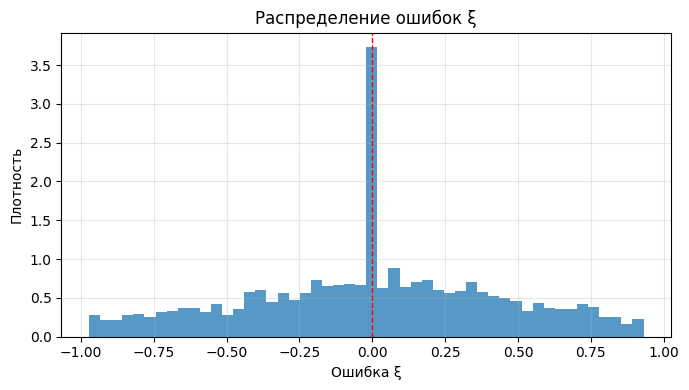

In [37]:
plt.figure(figsize=(7, 4))
plt.hist(res_trim, bins=50, density=True, alpha=0.75)
plt.axvline(0.0, color="red", linestyle="--", linewidth=1)

plt.title("Распределение ошибок ξ")
plt.xlabel("Ошибка ξ")
plt.ylabel("Плотность")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
from scipy.sparse.linalg import lsqr
import numpy as np

LAMBDA = 1.0  # попробуй 0.1, 1.0, 10.0

# augmented system: [X; sqrt(lambda)*I] beta ≈ [y; 0]
n_feat = X.shape[1]
X_aug = sp.vstack([X, np.sqrt(LAMBDA) * sp.eye(n_feat)], format="csr")
y_aug = np.concatenate([y, np.zeros(n_feat)])

res = lsqr(X_aug, y_aug)
coef_ridge = res[0]

a_r = coef_ridge[:n_players]
b_r = coef_ridge[n_players:]

print("Ridge done.")
print("a range:", float(a_r.min()), float(a_r.max()))
print("b range:", float(b_r.min()), float(b_r.max()))


Ridge done.
a range: -0.3220101266623739 0.277000741859301
b range: -1.0402558095799965 1.0587024700207697


In [24]:
# agg_f содержит p1..p5 как player_id из top_players
X_idx = np.zeros((len(agg_f), 5), dtype=np.int64)

for t, col in enumerate(players_cols):
    X_idx[:, t] = agg_f[col].map(player_to_idx).values

y_ht = agg_f["y_mean"].values.astype(np.float32)

print("X_idx shape:", X_idx.shape)
print("y_ht shape:", y_ht.shape)
print("X sample:\n", X_idx[:3])
print("y sample:", y_ht[:10])


X_idx shape: (3310, 5)
y_ht shape: (3310,)
X sample:
 [[299 287 127   0 183]
 [299 287 127   0  94]
 [299 287 127  54 217]]
y sample: [ 1.          1.         -0.11111111 -0.33333334  1.          1.
 -1.          0.          1.         -1.        ]


In [25]:
from sklearn.model_selection import train_test_split
import torch

SEED = 42
VAL_SIZE = 0.2

X_tr, X_va, y_tr, y_va = train_test_split(
    X_idx, y_ht, test_size=VAL_SIZE, random_state=SEED
)

y_mean = float(y_tr.mean())
y_std = float(y_tr.std() + 1e-6)

y_tr_n = (y_tr - y_mean) / y_std
y_va_n = (y_va - y_mean) / y_std

print("Train:", X_tr.shape, "Val:", X_va.shape)
print("y_mean:", y_mean, "y_std:", y_std)
print("y_tr_n sample:", y_tr_n[:5])


Train: (2648, 5) Val: (662, 5)
y_mean: 0.026893462985754013 y_std: 0.8053163886070251
y_tr_n sample: [ 1.2083532   1.2083532  -1.2751429  -1.2751429  -0.65426886]


In [27]:
import torch
import torch.nn as nn

class HTNode:
    """Узел HT-дерева (сбалансированное бинарное дерево)."""
    def __init__(self, rank, shapes, tensor_index, parent=None, node_type=None, dtype=torch.float32, device="cpu"):
        self.type = node_type
        self.tensor_index = tensor_index
        self.rank = rank
        self.parent = parent
        self.shapes = shapes
        self.dtype = dtype
        self.device = device
        self.core = None
        self.childrens = []

    def build_childrens(self):
        """Строим сбалансированное бинарное дерево."""
        n = len(self.shapes)
        if n == 1:
            self.type = "leaf"
            self.shapes = int(self.shapes[0])
            self.tensor_index = int(self.tensor_index[0])
            self.childrens = []
            return

        if self.type is None:
            self.type = "node"

        left_n = (n + 1) // 2
        self.childrens = [
            HTNode(rank=self.rank, shapes=self.shapes[:left_n], tensor_index=self.tensor_index[:left_n],
                   parent=self, node_type=None, dtype=self.dtype, device=self.device),
            HTNode(rank=self.rank, shapes=self.shapes[left_n:], tensor_index=self.tensor_index[left_n:],
                   parent=self, node_type=None, dtype=self.dtype, device=self.device),
        ]
        for ch in self.childrens:
            ch.build_childrens()

    def init_core(self):
        """Инициализация ядра узла."""
        # Xavier/Glorot для устойчивости
        if self.type == "leaf":
            core = torch.empty(self.shapes, self.rank, dtype=self.dtype, device=self.device)
            nn.init.xavier_uniform_(core)
        elif self.type == "node":
            core = torch.empty(self.rank, self.rank, self.rank, dtype=self.dtype, device=self.device)
            nn.init.xavier_uniform_(core)
        else:  # root
            core = torch.empty(self.rank, self.rank, 1, dtype=self.dtype, device=self.device)
            nn.init.xavier_uniform_(core)

        self.core = nn.Parameter(core)
        return self.core

    def init_core_all(self, cores_list):
        """Рекурсивно инициализируем ядра и собираем их в список."""
        cores_list.append(self.init_core())
        for ch in self.childrens:
            ch.init_core_all(cores_list)

    def evaluate(self, indices):
        """
        indices: (bs, dim) long
        Возвращает: (bs, rank) для всех узлов кроме root, для root: (bs, 1)
        """
        if self.type == "leaf":
            idx = indices[:, self.tensor_index]              # (bs,)
            return self.core[idx, :]                         # (bs, rank)

        left = self.childrens[0].evaluate(indices)           # (bs, rank)
        right = self.childrens[1].evaluate(indices)          # (bs, rank)

        # Контракция: left[α] * right[β] * core[α,β,γ] -> out[γ]
        out = torch.einsum("ka,kb,abc->kc", left, right, self.core)  # (bs, rank) или (bs,1) для root
        return out


class HTDecomposition(nn.Module):
    def __init__(self, shapes, rank=8, dtype=torch.float32, device="cpu"):
        super().__init__()
        self.shapes = tuple(int(s) for s in shapes)
        self.dim = len(self.shapes)
        self.rank = int(rank)
        self.dtype = dtype
        self.device = device

        self.root, cores = self._build_tree()
        self.cores = nn.ParameterList(cores)

    def _build_tree(self):
        root = HTNode(
            node_type="root",
            rank=self.rank,
            shapes=self.shapes,
            tensor_index=list(range(self.dim)),
            dtype=self.dtype,
            device=self.device,
        )
        root.build_childrens()

        cores = []
        root.init_core_all(cores)
        return root, cores

    def forward(self, idx):
        # idx: (bs, dim) long
        return self.root.evaluate(idx).squeeze(-1)  # (bs,)
    
    def __repr__(self):
        total = sum(p.numel() for p in self.parameters())
        return f"HTDecomposition(dim={self.dim}, rank={self.rank}, shapes={self.shapes}, params={total})"


In [28]:
import numpy as np
import torch
import torch.nn as nn

# ====== ОЖИДАЕМ, ЧТО УЖЕ ЕСТЬ: ======
# X_tr, X_va: numpy int64 (N,5), индексы 0..n_players-1
# y_tr_n, y_va_n: numpy float32 (N,)
# n_players: int

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# --- гиперпараметры (простые и рабочие) ---
HT_RANK = 8          # начни с 4 или 8 (16 пока не надо)
LR = 2e-3
EPOCHS = 60
BATCH_SIZE = 256
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

# --- модель: shapes = (n_players,..., n_players) 5 раз ---
shapes = (n_players, n_players, n_players, n_players, n_players)

model_ht = HTDecomposition(shapes=shapes, rank=HT_RANK, dtype=torch.float32, device=device).to(device)
print(model_ht)

opt = torch.optim.AdamW(model_ht.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
mse = nn.MSELoss()

# --- тензоры данных ---
X_tr_t = torch.tensor(X_tr, dtype=torch.long, device=device)
y_tr_t = torch.tensor(y_tr_n, dtype=torch.float32, device=device)
X_va_t = torch.tensor(X_va, dtype=torch.long, device=device)
y_va_t = torch.tensor(y_va_n, dtype=torch.float32, device=device)

def iterate_minibatches(X, y, bs):
    idx = torch.randperm(X.shape[0], device=X.device)
    for s in range(0, X.shape[0], bs):
        j = idx[s:s+bs]
        yield X[j], y[j]

best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    model_ht.train()
    train_losses = []

    for xb, yb in iterate_minibatches(X_tr_t, y_tr_t, BATCH_SIZE):
        opt.zero_grad(set_to_none=True)
        pred = model_ht(xb)
        loss = mse(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ht.parameters(), GRAD_CLIP)
        opt.step()
        train_losses.append(loss.detach().item())

    model_ht.eval()
    with torch.no_grad():
        pred_va = model_ht(X_va_t)
        val_loss = mse(pred_va, y_va_t).item()

    sched.step()

    train_loss = float(np.mean(train_losses))
    lr_now = opt.param_groups[0]["lr"]

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model_ht.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | train MSE={train_loss:.4f} | val MSE={val_loss:.4f} | lr={lr_now:.2e}")

print("\nTraining done. Best val MSE:", best_val)

# грузим лучший state
model_ht.load_state_dict(best_state)
model_ht.eval()

# быстрый sanity-check на валидации (первые 10)
with torch.no_grad():
    preds = model_ht(X_va_t[:10]).detach().cpu().numpy()
print("\nVAL preds (normalized) first 10:", np.round(preds, 3))
print("VAL true  (normalized) first 10:", np.round(y_va_n[:10], 3))


Device: cpu
HTDecomposition(dim=5, rank=8, shapes=(300, 300, 300, 300, 300), params=13600)
Epoch 001 | train MSE=1.0023 | val MSE=0.9857 | lr=2.00e-03
Epoch 005 | train MSE=1.0013 | val MSE=0.9857 | lr=1.97e-03
Epoch 010 | train MSE=0.8639 | val MSE=1.0928 | lr=1.87e-03
Epoch 015 | train MSE=0.6754 | val MSE=1.2859 | lr=1.71e-03
Epoch 020 | train MSE=0.6001 | val MSE=1.3737 | lr=1.50e-03
Epoch 025 | train MSE=0.5487 | val MSE=1.4402 | lr=1.26e-03
Epoch 030 | train MSE=0.5270 | val MSE=1.5197 | lr=1.00e-03
Epoch 035 | train MSE=0.5026 | val MSE=1.5881 | lr=7.41e-04
Epoch 040 | train MSE=0.4910 | val MSE=1.6523 | lr=5.00e-04
Epoch 045 | train MSE=0.4816 | val MSE=1.6936 | lr=2.93e-04
Epoch 050 | train MSE=0.4696 | val MSE=1.7118 | lr=1.34e-04
Epoch 055 | train MSE=0.4766 | val MSE=1.7201 | lr=3.41e-05
Epoch 060 | train MSE=0.4739 | val MSE=1.7216 | lr=0.00e+00

Training done. Best val MSE: 0.9853073358535767

VAL preds (normalized) first 10: [-0.002  0.006 -0.002 -0.002  0.    -0.009  0.

In [29]:
import numpy as np

MIN_OBS = 5  # попробуй 5, если всё равно шумно — 10

# agg_f: (p1..p5, y_mean, n_obs) после фильтра по top-300
# Сортируем индексы игроков в каждой пятёрке, чтобы модель была инвариантна к перестановкам
X_idx2 = np.zeros((len(agg_f), 5), dtype=np.int64)
for t, col in enumerate(players_cols):
    X_idx2[:, t] = agg_f[col].map(player_to_idx).values

X_idx2 = np.sort(X_idx2, axis=1)                 # <-- ВАЖНО: инвариантность
y_ht2 = agg_f["y_mean"].values.astype(np.float32)
nobs2 = agg_f["n_obs"].values.astype(np.int32)

mask = nobs2 >= MIN_OBS
X_idx2 = X_idx2[mask]
y_ht2 = y_ht2[mask]
nobs2 = nobs2[mask]

print("After MIN_OBS filter:", X_idx2.shape, "mean n_obs:", float(nobs2.mean()))
print("y sample:", y_ht2[:10])


After MIN_OBS filter: (813, 5) mean n_obs: 17.80319803198032
y sample: [-0.11111111 -0.46666667 -0.2         0.33333334  0.2         0.
 -0.2         0.6         0.04347826  0.2       ]


In [31]:
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2

X_tr, X_va, y_tr, y_va = train_test_split(
    X_idx2, y_ht2, test_size=VAL_SIZE, random_state=SEED
)

y_mean = float(y_tr.mean())
y_std = float(y_tr.std() + 1e-6)

y_tr_n = (y_tr - y_mean) / y_std
y_va_n = (y_va - y_mean) / y_std

print("Train:", X_tr.shape, "Val:", X_va.shape)
print("y_mean:", y_mean, "y_std:", y_std)
print("y_tr_n sample:", y_tr_n[:5])


Train: (650, 5) Val: (163, 5)
y_mean: 0.04724742844700813 y_std: 0.42796188592910767
y_tr_n sample: [-0.5777323  -1.8972561  -0.7780173  -1.1118253  -0.29014385]


In [32]:
HT_RANK = 4
LR = 1e-3
EPOCHS = 80
WEIGHT_DECAY = 5e-4


In [33]:
import torch
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"

@torch.no_grad()
def ht_predict_five(five_idx):
    five_idx = np.array(sorted(five_idx), dtype=np.int64)  # <-- сортировка
    x = torch.tensor(five_idx, dtype=torch.long, device=device).view(1, 5)
    pred_n = model_ht(x).item()
    pred = pred_n * y_std + y_mean
    return float(pred)

def greedy_five_ht(start_i, candidate_players, k=5):
    S = [start_i]
    while len(S) < k:
        best_j, best_val = None, -1e9
        for j in candidate_players:
            if j in S:
                continue
            val = ht_predict_five(S + [j])
            if val > best_val:
                best_val = val
                best_j = j
        S.append(best_j)
    return S, ht_predict_five(S)

# стартовые кандидаты: топ по a_i (как раньше)
start_candidates = [i for i, _ in players_ranked[:20]]
candidate_players = list(range(n_players))

best_ht_val = -1e9
best_ht_five = None

for i in start_candidates:
    five, val = greedy_five_ht(i, candidate_players, k=5)
    if val > best_ht_val:
        best_ht_val = val
        best_ht_five = five

def names_from_idx(five):
    return [id_to_name.get(idx_to_player[i], str(idx_to_player[i])) for i in five]

print("\n=== HT BEST FIVE ===")
print("HT predicted y_mean:", best_ht_val)
print("HT five:", names_from_idx(best_ht_five))

print("\n=== OLS BEST FIVE (previous) ===")
print("OLS score (model units):", float(ols_score(best_five, a, b, pair_to_idx)))
print("OLS five:", names_from_idx(best_five))


RuntimeError: shape '[1, 5]' is invalid for input of size 2